## 인공신경망 구조 Keras로 구현 (11장과 동일)

In [2]:
# pip install keras(파이썬에 직접 설치는 지양:Mac_ pip3 install keras)
import keras

model = keras.Sequential([
    # 첫 번째 은닉층: 2개의 뉴런, 입력은 64차원, 활성화 함수는 시그모이드
    keras.layers.Dense(2, activation='sigmoid', input_shape=(64,)),
    # 출력층: 1개의 뉴런, 활성화 함수는 시그모이드(이진 분류)
    keras.layers.Dense(1, activation='sigmoid')
])

/Users/juns/business_analytics/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/juns/business_analytics/.venv/lib/python3.9/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [3]:
#공식문서
model.compile(optimizer='SGD', loss='binary_crossentropy')

In [ ]:
#공식 문서
#모델값 넣어줘야함 (train, test 데이터)
model.fit(x_train, y_train, epochs=2000)

In [6]:
import numpy as np
from tensorflow import keras
from sklearn import datasets

# 손글씨 숫자 데이터 로드 및 전처리 (정규화, 이진 분류)
dataset = datasets.load_digits()
x_data = (dataset.data / 15.0).astype(np.float32)         # 입력값 0~1로 정규화
y_data = (dataset.target % 2).astype(np.float32)          # 짝수/홀수 이진 분류

from sklearn.model_selection import train_test_split
# 학습/테스트 데이터 분할 (20%를 테스트로 사용)
x_train, x_test, y_train, y_test = train_test_split(
    x_data, y_data, test_size=0.2
)

# 신경망 모델 정의 (은닉층 2개, 출력층 1개, 모두 시그모이드 활성화)
model = keras.Sequential([
    keras.layers.Dense(2, activation='sigmoid', input_shape=(64,)),
    keras.layers.Dense(1, activation='sigmoid')
])

# 모델 컴파일 (SGD 옵티마이저, 이진 크로스엔트로피 손실)
model.compile(optimizer='SGD', loss='binary_crossentropy')

# 모델 학습 (에포크 2000회)
model.fit(x_train, y_train, epochs=2000)

# 테스트 데이터에 대한 예측 (확률값 반환)
predictions = model.predict(x_test)
predLabels = []
for y in predictions:
    # 0.5 미만은 0(짝수), 0.5 이상은 1(홀수)로 변환
    if y < 0.5:
        predLabels.append(0)
    else:
        predLabels.append(1)

# 성능 평가 (혼동행렬, 분류 리포트)
from sklearn.metrics import confusion_matrix, classification_report
print(confusion_matrix(y_test, predLabels))
print(classification_report(y_test, predLabels))

Epoch 1/2000


/Users/juns/business_analytics/.venv/lib/python3.9/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 666us/step - loss: 0.7611
Epoch 2/2000
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 614us/step - loss: 0.7317
Epoch 3/2000
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 539us/step - loss: 0.7056
Epoch 4/2000
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 599us/step - loss: 0.6997
Epoch 5/2000
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 613us/step - loss: 0.6915
Epoch 6/2000
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 568us/step - loss: 0.6881
Epoch 7/2000
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 633us/step - loss: 0.6832
Epoch 8/2000
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 565us/step - loss: 0.6813
Epoch 9/2000
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 584us/step - loss: 0.6797
Epoch 10/2000
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 594us/step - loss: 0.6769
Epoch 11/2000
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 597us/step - loss: 0.6733
Epoch 12/2000
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 562us/step - loss: 0.6738
Epoch 13/2000
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 525us/step - loss: 0.6701
Epoch 14/2000
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 540us/step - loss: 0.6679
Epoch 15/2000
45/45 ━━━━━━━━━━━━━━━━━━━━ 0

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 7s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
(60000, 28, 28)
(60000,)
(10000, 28, 28)
(10000,)
Train label 0 = 9
[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   1   0   0  13  73   0
    0   1   4   0   0   0   0   1   1   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   3   0  36 136 127  62
   54   0   0   0   1   3   4   0   0   3]
 [  0   0   0   0   0   0   0   0   0   0   0   0   6   0 102 204 176 134
  144 123  23   0   0   0   0  12  10   0]
 [  0   0   0   0   0   0   0   0   0   0 

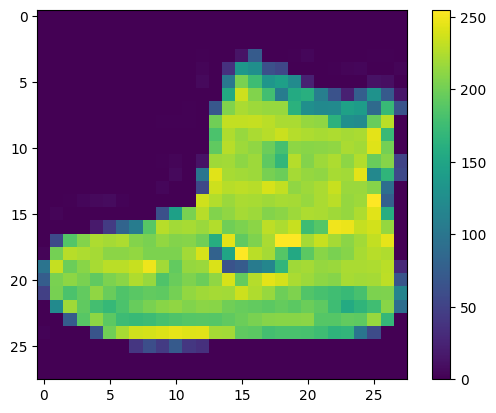

In [7]:
from tensorflow import keras

# 패션 MNIST 데이터셋 로드 (학습/테스트 데이터 자동 분리)
fashion_mnist = keras.datasets.fashion_mnist
(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()

# 데이터 형태(차원) 출력: 이미지(샘플수, 28, 28), 라벨(샘플수,)
print(train_images.shape)   # (60000, 28, 28)
print(train_labels.shape)   # (60000,)
print(test_images.shape)    # (10000, 28, 28)
print(test_labels.shape)    # (10000,)

# 0번 학습 데이터의 라벨과 실제 픽셀값 출력
print('Train label 0 =', train_labels[0])
print(train_images[0])

import matplotlib.pyplot as plt

# 0번 학습 이미지를 시각화
plt.imshow(train_images[0])
plt.colorbar()
plt.show()

In [8]:
from tensorflow import keras

# 패션 MNIST 데이터셋 로드
fashion_mnist = keras.datasets.fashion_mnist
(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()

# 입력값을 0~1로 정규화 (픽셀값을 255로 나눔)
train_images = train_images / 255.0
test_images = test_images / 255.0

# 신경망 모델 정의: 입력(28x28) → Flatten → Dense(100, relu) → Dense(10, softmax)
model = keras.Sequential([
    keras.layers.Flatten(input_shape=(28, 28)),         # 2D 이미지를 1D 벡터로 변환
    keras.layers.Dense(100, activation='relu'),         # 은닉층(100개 뉴런, ReLU)
    keras.layers.Dense(10, activation='softmax')        # 출력층(10개 클래스, 소프트맥스)
])

# 모델 컴파일: Adam 옵티마이저, 다중 클래스 분류 손실, 정확도 측정
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# 모델 학습 (에포크 10회)
model.fit(train_images, train_labels, epochs=10)

# 테스트 데이터에 대한 예측 (각 클래스별 확률 반환)
predictions = model.predict(test_images)

import numpy as np
predicted_labels = []
for p in predictions:
    predicted_labels.append(np.argmax(p))  # 확률이 가장 높은 클래스 선택

# 분류 성능 평가 (정밀도, 재현율, f1-score 등)
from sklearn.metrics import classification_report
print(classification_report(test_labels, predicted_labels))

/Users/juns/business_analytics/.venv/lib/python3.9/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 843us/step - accuracy: 0.7769 - loss: 0.6475
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 834us/step - accuracy: 0.8631 - loss: 0.3856
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8769 - loss: 0.3420
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8844 - loss: 0.3160
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 827us/step - accuracy: 0.8900 - loss: 0.2972
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 795us/step - accuracy: 0.8938 - loss: 0.2849
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 810us/step - accuracy: 0.9000 - loss: 0.2704
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 682us/step - accuracy: 0.9038 - loss: 0.2597
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 684us/step - accuracy: 0.9054 - loss: 0.2526
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 694us/step - accuracy: 0.9095 - loss: 0.2428
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 373us/step
              precision    recall  f1-score   support

     

/Users/juns/business_analytics/.venv/lib/python3.9/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 692us/step - loss: 0.6433
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 358us/step
Actual : 9 Ankle boot


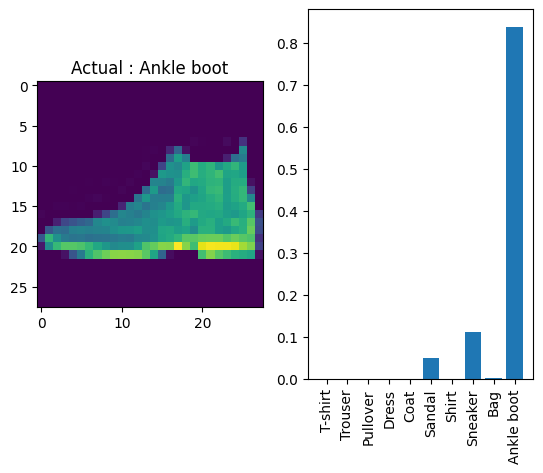

In [9]:
from tensorflow import keras

# 패션 MNIST 데이터셋 로드
fashion_mnist = keras.datasets.fashion_mnist
(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()

# 입력값을 0~1로 정규화
train_images = train_images / 255.0
test_images = test_images / 255.0

# 신경망 모델 정의: Flatten → Dense(100, relu) → Dense(10, softmax)
model = keras.Sequential([
    keras.layers.Flatten(input_shape=(28, 28)),
    keras.layers.Dense(100, activation='relu'),
    keras.layers.Dense(10, activation='softmax')
])

# 모델 컴파일 및 학습 (에포크 1회)
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy')
model.fit(train_images, train_labels, epochs=1)

# 테스트 데이터에 대한 예측 (각 클래스별 확률 반환)
predictions = model.predict(test_images)

import matplotlib.pyplot as plt

# 클래스 이름 리스트
names = ['T-shirt', 'Trouser', 'Pullover', 'Dress', 'Coat',
         'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

for i in range(1):  # 0번 샘플만 예시로 시각화
    print('Actual :', test_labels[i], names[test_labels[i]])
    plt.subplot(1, 2, 1)
    plt.imshow(test_images[i])
    plt.title('Actual : ' + names[test_labels[i]])
    plt.subplot(1, 2, 2)
    plt.bar(names, predictions[i])
    plt.xticks(rotation='vertical')
    plt.show()